In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px

Importing CSV Files

In [14]:
Orders_df = pd.read_csv(r"D:\(DATA) Data Analysis\Food_Delievery_(Orders).csv")
Restaurants_df = pd.read_csv(r"D:\(DATA) Data Analysis\Food_Delievery_(Resturants).csv")
print(Restaurants_df)
print(Orders_df)

    RestaurantID     RestaurantName       Cuisine    Zone  Category
0              1     The Cave Hotel   Continental  Zone B       Pro
1              2          SSK Hotel  North Indian  Zone D       Pro
2              3     ASR Restaurant  South Indian  Zone D  Ordinary
3              4          Win Hotel  South Indian  Zone D  Ordinary
4              5  Denver Restaurant   Continental  Zone D       Pro
5              6            Willies        French  Zone D       Pro
6              7                AMN  North Indian  Zone D  Ordinary
7              8               Oslo        French  Zone B  Ordinary
8              9   Excel Restaurant  North Indian  Zone D  Ordinary
9             10         Dave Hotel  South Indian  Zone A  Ordinary
10            11          The Taste        French  Zone B       Pro
11            12              Ruchi       Chinese  Zone B  Ordinary
12            13    Veer Restaurant       Chinese  Zone D  Ordinary
13            14          KSR Hotel       Chines

Merging Both CSV Files

In [31]:
Food_df = pd.merge(Orders_df, Restaurants_df , left_on='Restaurant ID', right_on='RestaurantID', how='inner')
Food_df = Food_df.drop(columns=['Restaurant ID'])
print(Food_df.head(5))


  Order ID Customer Name        Order Date  Quantity of Items  Order Amount  \
0      OD1         Srini  01-01-2022 23:15                  5           633   
1      OD2       Revandh  01-01-2022 19:21                  5           258   
2      OD3         David  01-01-2022 23:15                  7           594   
3      OD4         Selva  01-01-2022 20:31                  5           868   
4      OD5         Vinny  01-01-2022 11:10                  4           170   

       Payment Mode  Delivery Time Taken (mins)  Customer Rating-Food  \
0        Debit Card                          47                     5   
1       Credit Card                          41                     3   
2  Cash on Delivery                          30                     3   
3  Cash on Delivery                          30                     3   
4        Debit Card                          18                     4   

   Customer Rating-Delivery  RestaurantID    RestaurantName       Cuisine  \
0        

Top Restaurants by Revenue


In [35]:
Top_Restaurants_Revenue = Food_df.groupby('RestaurantName')['Order Amount'].sum().sort_values(ascending=False)
Top_Restaurants_Revenue.to_excel('Top_Restaurants_Revenue.xlsx')
print(Top_Restaurants_Revenue.head(5))

RestaurantName
Veer Restaurant     19168
The Cave Hotel      18934
Anand Restaurant    18589
Willies             18324
Ellora              17863
Name: Order Amount, dtype: int64


Popular Cuisines by Zone


In [46]:
Popular_Cuisines_by_Zones = Food_df.groupby(['Zone', 'Cuisine'])['Order ID'].count().reset_index(name='Order_Count').sort_values(['Zone', 'Order_Count'], ascending=(True, False))
Popular_Cuisines_by_Zones.to_excel('Popular_Cuisines_by_Zones.xlsx')
print(Popular_Cuisines_by_Zones)

      Zone       Cuisine  Order_Count
0   Zone A       Belgian           25
1   Zone A       Chinese           24
2   Zone A  South Indian           20
6   Zone B        French           41
5   Zone B   Continental           32
3   Zone B       Belgian           31
4   Zone B       Chinese           28
7   Zone C       African           61
8   Zone C       Arabian           25
12  Zone D  North Indian           81
13  Zone D  South Indian           50
11  Zone D        French           30
9   Zone D       Chinese           29
10  Zone D   Continental           23


Average Spending per Customer


In [55]:
Avg_Spending_Customer = Food_df.groupby('Customer Name')['Order Amount'].mean().sort_values(ascending=False)
Avg_Spending_Customer.to_excel('Avg_Spending_Customer.xlsx')
print(Avg_Spending_Customer.head(5))

Customer Name
Veer        691.884615
Charlie     674.166667
Vinny       662.909091
Farhan      655.680000
Veronica    650.500000
Name: Order Amount, dtype: float64


Customer Ratings Distribution


In [ ]:
Customer_Rating_Dist = (
    Food_df.groupby('Customer Name')[['Customer Rating-Food', 'Customer Rating-Delivery']]
    .mean()
    .round(2)
    .reset_index()
)
Customer_Rating_Dist.to_excel('Customer_Rating_Dist.xlsx')
print(Customer_Rating_Dist)

   Customer Name  Customer Rating-Food  Customer Rating-Delivery
0        Charlie                  3.50                      2.79
1         Chinny                  3.42                      2.84
2          David                  3.17                      3.54
3            Dev                  3.79                      3.08
4         Farhan                  3.72                      3.08
5         Fastin                  3.67                      2.80
6          Gopal                  3.00                      3.10
7          Meera                  3.21                      2.83
8            Ram                  3.45                      2.76
9        Revandh                  3.57                      3.10
10          Rifa                  3.32                      2.96
11       Sabeena                  2.88                      3.29
12         Selva                  3.10                      2.90
13         Shifa                  3.45                      2.40
14         Srini         

Delivery Performance


In [78]:
Delivery_Perf = Food_df.groupby('RestaurantName')['Delivery Time Taken (mins)'].mean().round(2).sort_values(ascending=False)
Delivery_Perf.to_excel('Delivery_Perf.xlsx')
print(Delivery_Perf)

RestaurantName
Ruchi                33.61
Ellora               32.19
Anand Restaurant     32.07
Vrinda Bhavan        32.00
Chew Restaurant      31.81
Willies              31.60
ASR Restaurant       31.57
Veer Restaurant      31.31
Sam Hotel            31.08
KSR Hotel            30.96
Win Hotel            30.96
SSK Hotel            30.80
Oslo                 30.65
AMN                  30.32
The Taste            29.72
Denver Restaurant    29.13
Excel Restaurant     28.39
Zam Zam              28.20
Dave Hotel           27.50
The Cave Hotel       26.03
Name: Delivery Time Taken (mins), dtype: float64


Does delivery speed affect ratings?


Correlation between Delivery Time and Delivery Rating: -0.051


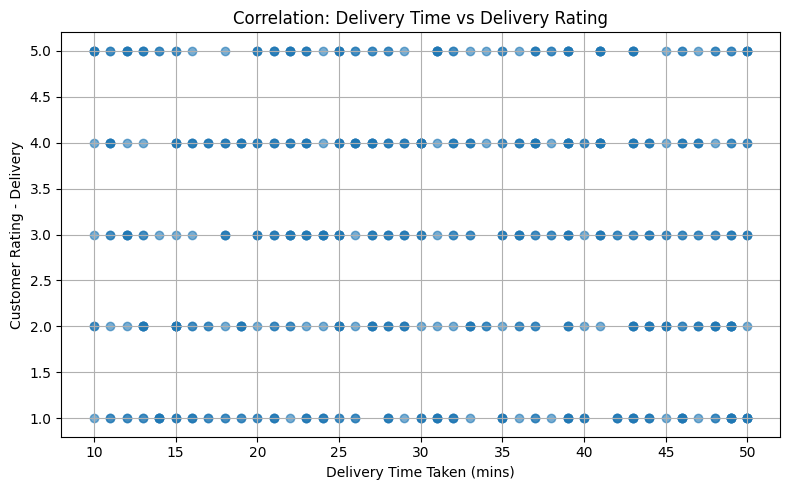

In [89]:
correlation = Food_df['Delivery Time Taken (mins)'].corr(Food_df['Customer Rating-Delivery'])
print("Correlation between Delivery Time and Delivery Rating:", round(correlation, 3))

plt.figure(figsize=(8, 5))
plt.scatter(Food_df['Delivery Time Taken (mins)'], Food_df['Customer Rating-Delivery'], alpha=0.6)
plt.title('Correlation: Delivery Time vs Delivery Rating')
plt.xlabel('Delivery Time Taken (mins)')
plt.ylabel('Customer Rating - Delivery')
plt.grid(True)
plt.tight_layout()
plt.savefig('Correlation: Delivery Time vs Delivery Rating.png')
plt.show()


Are higher prices associated with better food ratings?


-0.0513007801067603


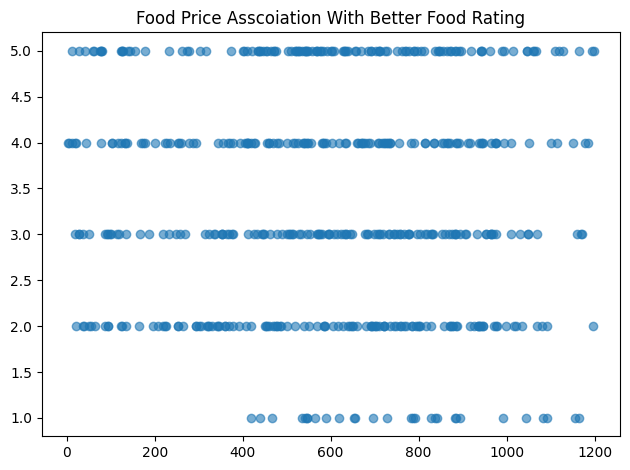

In [92]:
Price_vs_food_rating = Food_df['Order Amount'].corr(Food_df['Customer Rating-Food'])
print(Price_vs_food_rating)

plt.Figure(figsize=(8,6))
plt.scatter(Food_df['Order Amount'], Food_df['Customer Rating-Food'], alpha=0.6)
plt.title('Food Price Asscoiation With Better Food Rating')
plt.grid=True
plt.tight_layout()
plt.savefig('Price_vs_food_rating.png')
plt.show()

Cuisine vs. Customer Rating


        Cuisine  Customer Rating-Food  Customer Rating-Delivery
6  North Indian                  3.59                      3.00
0       African                  3.46                      3.08
1       Arabian                  3.44                      3.08
4   Continental                  3.38                      3.07
3       Chinese                  3.31                      2.85
5        French                  3.27                      2.96
2       Belgian                  3.25                      2.64
7  South Indian                  3.21                      3.29


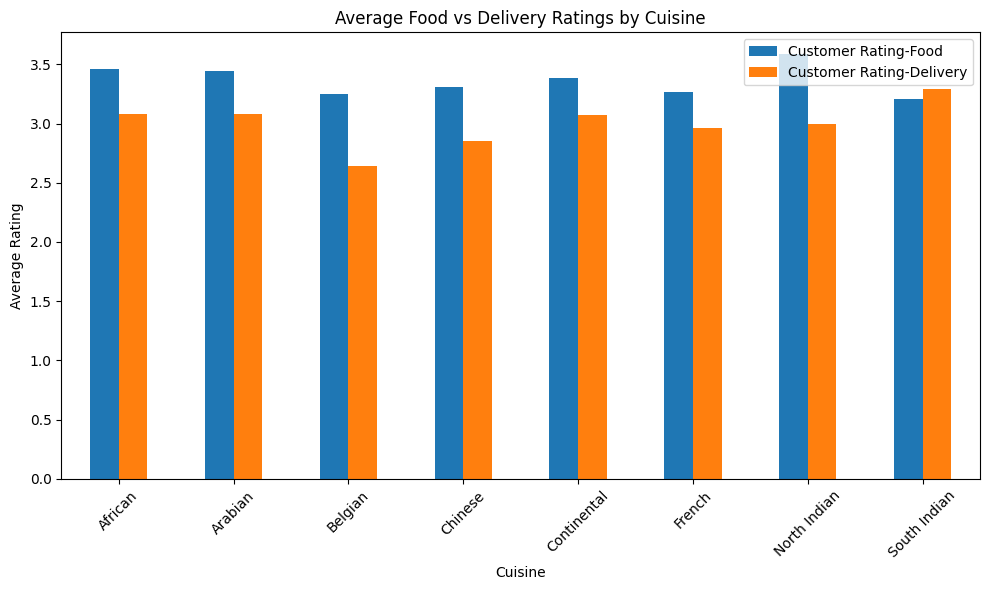

In [96]:
Cuisine_Rating = (
    Food_df.groupby('Cuisine')[['Customer Rating-Food', 'Customer Rating-Delivery']]
    .mean()
    .round(2)
    .reset_index()
)
Cuisine_Rating.to_excel('Cuisine_Rating.xlsx')
print(Cuisine_Rating.sort_values('Customer Rating-Food', ascending=False))

Cuisine_Rating.plot(
    x='Cuisine',
    y=['Customer Rating-Food', 'Customer Rating-Delivery'],
    kind='bar',
    figsize=(10,6)
)
plt.title('Average Food vs Delivery Ratings by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Average Food vs Delivery Ratings by Cuisine')
plt.show()



Payment Mode Preference Analysis


High-Value Order threshold: 828.5
       Payment Mode  Count
0        Debit Card     51
1  Cash on Delivery     38
2       Credit Card     36


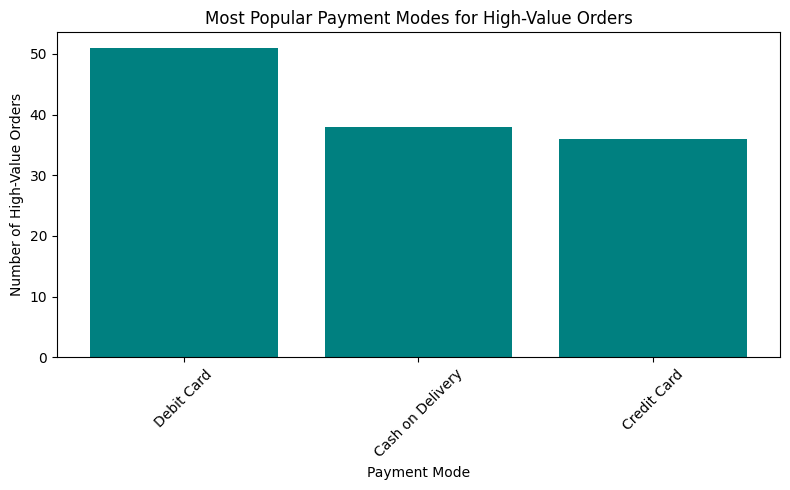

In [114]:
threshold = Food_df['Order Amount'].quantile(0.75)
print('High-Value Order threshold:', threshold)

High_Value_Orders = Food_df[Food_df['Order Amount']>threshold]

Payment_Mode_Popularity = (
    High_Value_Orders['Payment Mode']
    .dropna()
    .value_counts()
    .rename_axis('Payment Mode')
    .reset_index(name='Count')
)
Payment_Mode_Popularity.to_excel('Payment_Mode_Popularity.xlsx')
print(Payment_Mode_Popularity)


plt.figure(figsize=(8,5))
plt.bar(Payment_Mode_Popularity['Payment Mode'], Payment_Mode_Popularity['Count'], color='teal')
plt.title('Most Popular Payment Modes for High-Value Orders')
plt.xlabel('Payment Mode')
plt.ylabel('Number of High-Value Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Payment_Mode_Popularity.png')
plt.show()


Zone vs. Delivery Efficiency


Zone
Zone C    30.99
Zone D    30.69
Zone B    30.30
Zone A    30.00
Name: Delivery Time Taken (mins), dtype: float64


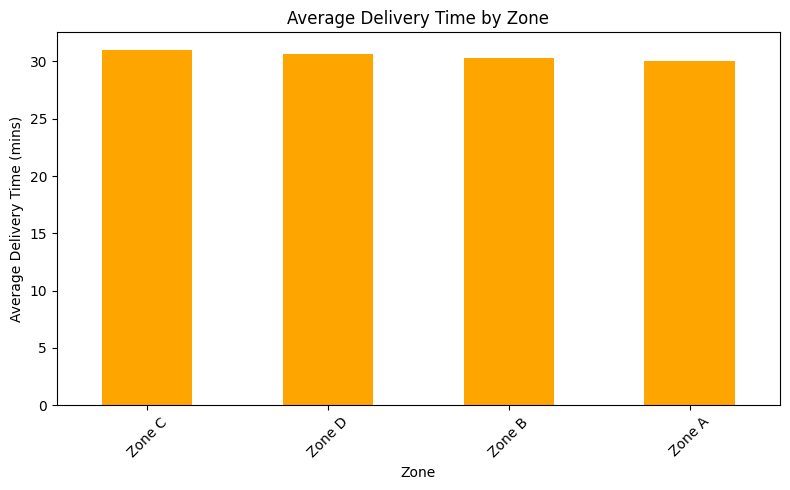

In [117]:
Zone_vs_Delivery = Food_df.groupby('Zone')['Delivery Time Taken (mins)'].mean().round(2).sort_values(ascending=False)
Zone_vs_Delivery.to_excel('Zone_vs_Delivery.xlsx')
print(Zone_vs_Delivery)

Zone_vs_Delivery.plot(kind='bar', color='orange', figsize=(8,5))
plt.title('Average Delivery Time by Zone')
plt.xlabel('Zone')
plt.ylabel('Average Delivery Time (mins)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Zone_vs_Delivery.png')
plt.show()


Interactive Heatmap of Ratings by Zone & Cuisine


In [124]:
heatmap_data = (
    Food_df.pivot_table(
        index='Zone',
        columns='Cuisine',
        values='Customer Rating-Food',
        aggfunc='mean'
    )
    .round(2)
)

fig = px.imshow(
    heatmap_data,
    color_continuous_scale='YlOrRd',
    labels={'color': 'Avg Food Rating'},
    title='Interactive Heatmap: Average Food Rating by Zone & Cuisine'
)
fig.update_xaxes(side='top')
fig.write_image('Interactive Heatmap Average Food Rating by Zone  Cuisine.png')
fig.show()



Pie Chart of Payment Mode Usage


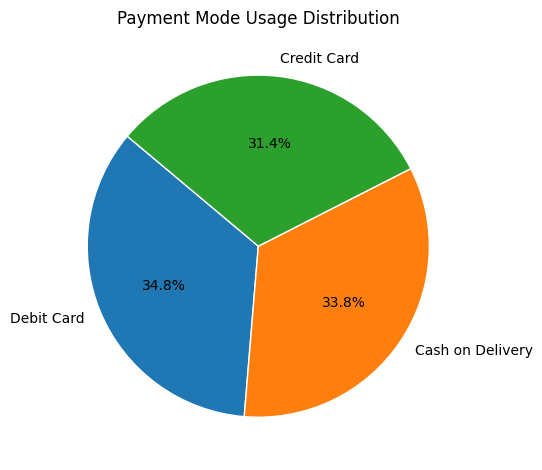

In [125]:
Payment_Counts = Food_df['Payment Mode'].value_counts()

plt.Figure(figsize=(7,7))
plt.pie(
    Payment_Counts,
    labels=Payment_Counts.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'white'}
)
plt.title('Payment Mode Usage Distribution')
plt.tight_layout()
plt.savefig('Payment Mode Usage Distribution.png')
plt.show()

Boxplot of Delivery Times by Cuisine Type

In [127]:
fig = px.box(
    Food_df,
    x='Cuisine',
    y='Delivery Time Taken (mins)',
    color='Cuisine',
    title='Interactive Boxplot of Delivery Times by Cuisine',
    points='all'  # shows all individual data points
)
fig.update_layout(
    xaxis_title='Cuisine Type',
    yaxis_title='Delivery Time (mins)',
    showlegend=False
)
fig.write_image('Interactive Boxplot of Delivery Times by Cuisine.png')
fig.show()

